run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now

import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import random
input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'#'/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)
# The limit of samples with midi notes off to be put into the trainingset

# sailent_thresh=20000 
# current_sailent_count=np.zeros(89,dtype=int)
# selected_outfiles=[]
# selected_infiles=[]
 
# rng=np.random.default_rng(123)
# perm=rng.permutation(len(output_filepaths))
# output_filepaths=[output_filepaths[i] for i in perm]
# input_filepaths=[input_filepaths[i] for i in perm]
# # for i,output_filepath in enumerate(output_filepaths):
# #     output_data=np.load(output_filepath)


#     # # print(output_data.shape)
#     # # print("out path:", output_filepath)
#     # # print("in path:", input_filepaths[i])
#     # if output_data[0][88]>0:
#     #     if current_sailent_count[88]<sailent_thresh:
#     #         selected_outfiles.append(output_filepath)
#     #         selected_infiles.append(input_filepaths[i])
#     #         current_sailent_count[88]+=1
#     # else:
#     #     selected_outfiles.append(output_filepath)
#     #     selected_infiles.append(input_filepaths[i])


# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)
#     copydata=True
#     for note in range(89):
#         if output_data[0][note]>0:
#             if current_sailent_count[note]>sailent_thresh:
#                 copydata=False

#     # print(output_data.shape)
#     # print("out path:", output_filepath)
#     # print("in path:", input_filepaths[i])

#     if copydata:
#         selected_outfiles.append(output_filepath)
#         selected_infiles.append(input_filepaths[i])
#         for note in range(89):
#             if output_data[0][note]>0:
#                 current_sailent_count[note]+=1
# input_filepaths=selected_infiles
# output_filepaths=selected_outfiles
print("selected files: input: ",len(input_filepaths))

I0000 00:00:1770342860.940196 1231831 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1770342860.966717 1231831 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1770342861.505354 1231831 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1770342862.153334 1231831 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel bi

Filter mask created with shape: (312, 513)
selected files: input:  29504


Mixed precision policy set to 'mixed_float16'.
Error configuring GPU: Physical devices cannot be modified after being initialized
TensorFlow version: 2.21.0-dev20251016
Batch size: 64
Learning rate: 0.001
Epochs: 100
Estimated total samples: 6299921.250984362
Steps per epoch: 98436
Initial input shape: (64, 312, 2048)
After first Conv2D: (64, 156, 64)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (64, 312, 1024, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (64, 312, 1024, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (64, 312, 128, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (64, 312, 128, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (64, 312, 2048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (64, 312, 32)          │       327,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (64, 312, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (64, 312, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (64, 312, 32)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (64, 312, 64)          │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (64, 312, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (64, 312, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (64, 156, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (64, 156, 64)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (64, 156, 128)         │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (64, 156, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (64, 156, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (64, 78, 128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (64, 78, 128)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (64, 128)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 396,913 (1.51 MB)

 Trainable params: 396,465 (1.51 MB)

 Non-trainable params: 448 (1.75 KB)

Found 29504 files on disk.
Fretboards created: 29504
Using mapped dataset loading.
Filter mask created with shape: (312, 2049)

--- Starting CNN Model Training with Sample Weights ---


I0000 00:00:1770342863.610086 1231831 profiler_session.cc:103] Profiler session initializing.
I0000 00:00:1770342863.610104 1231831 profiler_session.cc:118] Profiler session started.
I0000 00:00:1770342863.610114 1231831 cupti_tracer.cc:1075] Profiler found 1 GPUs
I0000 00:00:1770342863.617341 1231831 profiler_session.cc:136] Profiler session tear down.
I0000 00:00:1770342863.617391 1231831 cupti_tracer.cc:1421] CUPTI activity buffer flushed


Epoch 1/100
An error occurred during training: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 312, 1024, 1), found shape=(64, 312, 4096)


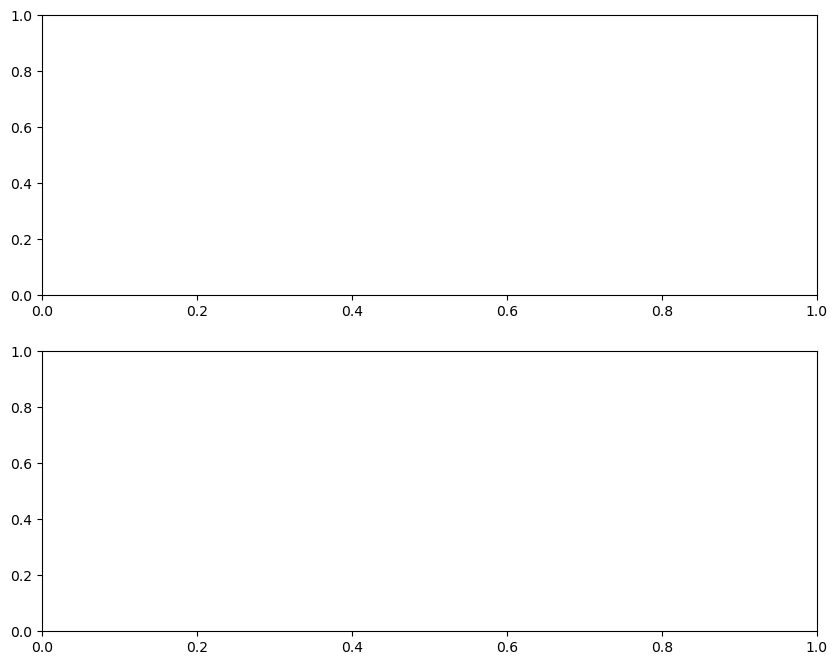

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_1d_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,tf_load_sample_from_files,SAMPLERATE,feature_description,INPUT_SHAPE_AUDIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import datetime
from fretboard import FretBoard
from scipy import signal
# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.001
BATCH_SIZE = 64#2048
EPOCHS = 100
print("Batch size:",BATCH_SIZE)
print("Learning rate:",LEARNING_RATE)
print("Epochs:",EPOCHS)
SAMPLES=504000000000/(312*256+129) # Rough estimate of total samples in dataset
print("Estimated total samples:",SAMPLES)
STEPS_PER_EPOCH = int(SAMPLES // BATCH_SIZE)
print("Steps per epoch:",STEPS_PER_EPOCH)
VALIDATION_STEPS =  2000


# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training/output'
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'


# --- 4. Model Definition and Compilation (Using built-in loss) ---

# cnn_model = build_cnn_model(common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model = build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='bin_acc'), # Measures individual bit correctness
        tf.keras.metrics.Precision(name='precision'), 
        tf.keras.metrics.Recall(name='recall')
    ],
    jit_compile=True
)

cnn_model.summary()


# --- 5. Custom Callback for Live Loss Plotting (omitted for brevity, assume definition remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_bin_acc = []
        self.epochs_run = []
        self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(2, 1, figsize=(10, 8))
            # Save model summary to string
        summary_list = []
        self.model.summary(print_fn=lambda x: summary_list.append(x))
        self.model_summary = '\n'.join(summary_list)
        
        # Save summary to file
        with open('model_summary.txt', 'w') as f:
            f.write(self.model_summary)

    def on_epoch_end(self, epoch, logs=None):
        # local import so notebook output display works even when executed headless
        from IPython.display import display, Image, clear_output

        logs = logs or {}
        self.epochs_run.append(epoch + 1)

        # safe conversion to numbers (use NaN if missing)
        self.losses.append(float(logs.get('loss')) if logs.get('loss') is not None else np.nan)
        self.val_losses.append(float(logs.get('val_loss')) if logs.get('val_loss') is not None else np.nan)

        # support both 'accuracy' and 'acc' keys
        acc_val = logs.get('accuracy') if 'accuracy' in logs else logs.get('acc')
        val_bin_acc_val = logs.get('val_bin_acc') if 'val_bin_acc' in logs else logs.get('val_bin_acc')
        self.acc.append(float(acc_val) if acc_val is not None else np.nan)
        self.val_bin_acc.append(float(val_bin_acc_val) if val_bin_acc_val is not None else np.nan)

        # clear previous cell output, draw and save figure, then display saved PNG so it remains in notebook
        clear_output(wait=True)
        # Print model summary first
        print("Model Architecture:")
        print("-" * 80)
        print(self.model_summary)
        print("-" * 80)
        #print(f"\nTraining Progress - Epoch {epoch + 1}/{self.model.epochs}")

        # Loss subplot
        self.ax_loss.clear()
        self.ax_loss.plot(self.epochs_run, self.losses, label='Training Loss', color='tab:blue')
        if any(~np.isnan(self.val_losses)):
            self.ax_loss.plot(self.epochs_run[:len(self.val_losses)], self.val_losses, label='Validation Loss', color='tab:orange')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.legend(loc='upper right')
        self.ax_loss.grid(True)

        # Accuracy subplot
        self.ax_acc.clear()
        self.ax_acc.plot(self.epochs_run, self.acc, label='Training Accuracy', color='tab:green')
        if any(~np.isnan(self.val_bin_acc)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_bin_acc)], self.val_bin_acc, label='Validation Accuracy', color='tab:red')
        self.ax_acc.set_xlabel('Epoch')
        self.ax_acc.set_ylabel('Accuracy')
        self.ax_acc.set_ylim(0.0, 1.0)
        self.ax_acc.legend(loc='lower right')
        self.ax_acc.grid(True)

        self.fig.tight_layout()
        self.fig.savefig("training.png", bbox_inches='tight')  # persist image
        display(Image("training.png"))  # embed PNG in notebook output so it remains visible
        plt.close(self.fig)  # close to free memory; will recreate on next epoch

# --- 6. Data Loading and Preparation (Modified to include weights) ---


# output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
# if total_samples_on_disk == 0 or total_samples_on_disk != len(output_filepaths):
#     print("ERROR: Data files not found or mismatch.")
#     exit()

print(f"Found {total_samples_on_disk} files on disk.")

# def count_tfrecord_samples(filepaths):
#     total = 0
#     for filepath in filepaths:
#         dataset = tf.data.TFRecordDataset(filepath)
#         total += sum(1 for _ in dataset)  # Pure Python count
#     return total

# total_samples = count_tfrecord_samples(input_filepaths)
# STEPS_PER_EPOCH = total_samples // BATCH_SIZE
# print(f"Total samples: {total_samples}, Steps: {STEPS_PER_EPOCH}")


# We need to map the data to (feature, label, weight) tuples for tf.data
# The weight for each sample will be the 'element_weights' vector defined above.


def batch_with_weights(dataset):
    def _stack_fn(images, labels, weights):
        return (tf.stack(images), tf.stack(labels), tf.stack(weights))
    return dataset.batch(BATCH_SIZE).map(_stack_fn, num_parallel_calls=tf.data.AUTOTUNE)

#create a list of filterbanks of equal length to the number of input files
fretboard=FretBoard(17.5,SAMPLERATE)
fretboards=[fretboard for _ in range(len(input_filepaths))]
fretboard_ids=tf.data.Dataset.range(len(fretboards))
print("Fretboards created:",len(fretboards))

# Create a dataset from the lists of file paths
dataset = tf.data.TFRecordDataset(input_filepaths,num_parallel_reads=tf.data.AUTOTUNE)# 
# dataset=tf.data.Dataset.from_tensor_slices((input_filepaths))
#dataset = dataset.shuffle(buffer_size=total_samples_on_disk) #Dont randomize since we need the temporal order for RNNs

split_ratio = 0.8
split_idx = int(len(input_filepaths) * split_ratio)
train_filepaths = input_filepaths[:split_idx]    # First 70% of FILES


val_filepaths = input_filepaths[split_idx:]      # Last 30% of FILES


train_with_mapping = True

if train_with_mapping:
    print("Using mapped dataset loading.")
    train_audio_ds = tf.data.TFRecordDataset(train_filepaths)
    train_fret_ds=fretboard_ids.take(split_idx)
    train_files = tf.data.Dataset.zip((train_audio_ds, train_fret_ds))
    val_audio_ds = tf.data.TFRecordDataset(val_filepaths)
    val_fret_ds=fretboard_ids.skip(split_idx)
    val_files = tf.data.Dataset.zip((val_audio_ds, val_fret_ds))
else:
    print("Using interleaved dataset loading.")
    train_files=tf.data.Dataset.from_tensor_slices((train_filepaths,train_fretboards))
    val_files=tf.data.Dataset.from_tensor_slices((val_filepaths,val_fretboards))
def create_static_mask(fretboard_obj, num_samples, sample_rate):
    freq_bins = num_samples // 2 + 1
    # Use logspace for frequency bins to better match musical intervals
    f = np.linspace(0, sample_rate / 2, freq_bins)
    mask = []
    
    for fret in fretboard_obj.frets:
        for string in fret.strings:
            for filt in string.harmonics:
                # Use freqz to get the response
                w, h = signal.freqz(filt.b, filt.a, worN=f, fs=sample_rate)
                
                # Apply the square for filtfilt simulation
                response = np.abs(h)**2
                
                # --- VITAL NORMALIZATION ---
                # Ensure every single filter has a peak of exactly 1.0
                p_max = np.max(response)
                if p_max > 1e-12:
                    response = response / p_max
                else:
                    # If the filter is "dead", create a tiny Gaussian peak at the target freq
                    # so the model at least sees SOMETHING.
                    pass 
                
                mask.append(response)
                
    return tf.constant(np.array(mask), dtype=tf.complex64)

# Global constant
FILTER_MASK = create_static_mask(fretboard, INPUT_SHAPE_AUDIO[1], SAMPLERATE)
# 1. Create static window outside the map function

HANNING = tf.cast(tf.signal.hann_window(INPUT_SHAPE_AUDIO[1]), tf.float32)
print("Filter mask created with shape:", FILTER_MASK.shape)
def fast_gpu_map(ipath, fretboard_idx,training=True):
    parsed = tf.io.parse_single_example(ipath, feature_description)
    audio = tf.io.decode_raw(parsed["input"], tf.float32)
    label = tf.io.decode_raw(parsed["output"], tf.int8)

    audio = audio * HANNING
    # normalize audio to [-1, 1] if audio volume is above -40db    
    # 1. Calculate the Peak
    peak = tf.reduce_max(tf.abs(audio))
    
    # 2. Set -40dB Threshold (0.01 linear)
    threshold = 0.01 
    
    # 3. Apply Conditional Normalization
    # If peak > 0.01, normalize to 1.0. Else, kill the signal to 0.0.
    audio = tf.cond(
        peak > threshold,
        lambda: audio / (peak + 1e-6),
        lambda: audio * 0.0
    )


    if training:
        audio, label = augment_audio(audio, label)
    # --- Vectorized Filtering ---
    # 1. FFT
    audio_fft = tf.signal.rfft(audio) 
    # 2. Apply all 312 filters at once (Broadcasting)
    # [312, Freq] * [Freq]
    filtered_fft = FILTER_MASK * tf.cast(audio_fft, tf.complex64)
    # 3. IFFT + Absolute (Envelope)
    envelopes = tf.abs(tf.signal.irfft(filtered_fft)) # Shape: [312, Time]
    # if training:
    #     envelopes, label = augment_audio(envelopes, label) 
    # Reshape for CNN
    input_tensor = tf.cast(envelopes, tf.float32)
    input_tensor = tf.expand_dims(input_tensor, axis=-1)
    output_tensor = tf.cast(tf.reshape(label, [OUTPUT_DIM_NOTES]), tf.float32)
    
    return input_tensor, output_tensor
def augment_audio(audio, label):
    # Randomly scale volume (0.5x to 1.2x)
    gain = tf.random.uniform([], 0.5, 1.2)
    audio = audio * gain
    
    # Add a tiny bit of white noise to mask filter "ringing"
    noise = tf.random.normal(shape=tf.shape(audio), stddev=0.01)
    return audio + noise, label
# TensorFlow wrapper for loading sample from files
def tf_load_and_filter_sample_from_files(ipath, fretboard_idx):
    parsed = tf.io.parse_single_example(ipath, feature_description)
    input_raw = tf.io.decode_raw(parsed["input"], tf.float32)
    output_raw = tf.io.decode_raw(parsed["output"], tf.int8)

    # 1. Run the py_function
    input_tensor = tf.py_function(func=process_audio, inp=[input_raw, fretboard_idx], Tout=tf.float32)
    
    # 2. FIX: Manually set the shape! 
    # Replace these variables with your actual expected dimensions 
    # (e.g., [312, 129, 1])
    input_tensor.set_shape([common.INPUT_SHAPE[0], common.INPUT_SHAPE[1], common.INPUT_SHAPE[2]])

    output_tensor = tf.cast(tf.reshape(output_raw, [OUTPUT_DIM_NOTES]), tf.float32)
    output_tensor.set_shape([OUTPUT_DIM_NOTES]) # Good practice to set this too

    return input_tensor, output_tensor
def process_audio(audio, fretboard_idx):
    #print("Processing audio with fretboard index:", fretboard_idx.numpy())
    numfilters=fretboard.get_num_filters()#fretboards[fretboard_idx].get_num_filters()
    #print("Number of filters:", numfilters)
    filterbank_out=np.zeros((numfilters,INPUT_SHAPE_AUDIO[1]),dtype=np.float32)
    #print("Filterbank output shape:", filterbank_out.shape)
    # Cast input_tensor to np array for processing
    audio_np = audio.numpy().squeeze()  # Remove batch dimension if present
    #print("Audio numpy shape:", audio_np.shape)
    fretboard.process(audio_np,filterbank_out)#fretboards[fretboard_idx].process(input_np,filterbank_out)
    #print("Filterbank processed.")
    filterbank_out=tf.reshape(filterbank_out,(numfilters,INPUT_SHAPE_AUDIO[1],1))
    #print("Filterbank reshaped to:", filterbank_out.shape)
    audio_tensor = tf.cast(filterbank_out, tf.float32)
    #print("Audio tensor shape:", audio_tensor.shape)
    return audio_tensor

def map_func(input_path):
    # 1. Load the raw TFRecord
    ds = tf.data.TFRecordDataset(input_path, num_parallel_reads=tf.data.AUTOTUNE)
    
    # 2. Parse the record into (features, labels)
    ds = ds.map(tf_load_sample_from_files, num_parallel_calls=tf.data.AUTOTUNE)
    
    # 3. Apply Spectral Gain / Volume Augmentation
    def augment(features, labels):
        # Randomly scale volume between 0.5 (half volume) and 1.5 (extra loud)
        # This prevents the model from relying on specific "loudness" to find a note
        gain = tf.random.uniform([], 0.5, 1.5)
        features = features * gain
        
        # Add a tiny bit of random hiss (noise)
        # This solves the "Ringing A" by making the model ignore low-level noise
        noise = tf.random.normal(shape=tf.shape(features), stddev=0.002)
        return features + noise, labels

    return ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


# Map loading function (now includes the weight vector)
if train_with_mapping:
    train_dataset = train_files.shuffle(BATCH_SIZE * 2).map(lambda path, idx: fast_gpu_map(path, idx, training=True), num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_files.shuffle(BATCH_SIZE * 2).map(lambda path, idx: fast_gpu_map(path, idx, training=False), num_parallel_calls=tf.data.AUTOTUNE)
else:
    # Increase the number of parallel workers to overwhelm the bottleneck
    train_dataset = train_files.interleave(
        map_func,
        cycle_length=32,          # Open 32 files at once
        block_length=16,        # Read 16 samples from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False       # Essential for speed
    )


    val_dataset = val_files.interleave(
        map_func,
        cycle_length=32,          # Open 32 files at once
        block_length=16,        # Read 16 samples from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False       # Essential for speed
    )



# Apply batching and prefetching  (use train/val_dataset.cache().batch... if needed)
train_dataset = train_dataset.repeat().batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.repeat().batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
# train_dataset = batch_with_weights(train_dataset).prefetch(tf.data.AUTOTUNE)
# val_dataset = batch_with_weights(val_dataset).prefetch(tf.data.AUTOTUNE)

# --- 7. Training the Model (Passing the element-wise weight) ---

plot_callback = PlotLoss()
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=5,   
    min_delta=0.0001, 
    mode='min',          
    verbose=1,           
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
checkpoint=ModelCheckpoint('checkpoints/guitarmidi_epoch{epoch:02d}_valAcc{val_bin_acc:.4f}.weights.h5', save_weights_only=True,save_freq='epoch')
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
        histogram_freq=1,  # Log weight histograms every epoch
        write_graph=True,
        write_images=True,
        update_freq='epoch',
        profile_batch='10,20',  # Profile batches 10-20 for performance analysis
        embeddings_freq=1)
# initial_learning_rate = LEARNING_RATE
# warmup_epochs = 5

# class WarmUpLearningRateScheduler(tf.keras.callbacks.Callback):
#     def __init__(self, warmup_epochs, initial_lr):
#         super().__init__()
#         self.warmup_epochs = warmup_epochs
#         self.initial_lr = initial_lr
        
#     def on_epoch_begin(self, epoch, logs=None):
#         if epoch < self.warmup_epochs:
#             lr = self.initial_lr * ((epoch + 1) / self.warmup_epochs)
#             tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
#             print(f'\nEpoch {epoch+1}: WarmUp LR set to {lr}')

# warmup = WarmUpLearningRateScheduler(warmup_epochs, initial_learning_rate)

print("\n--- Starting CNN Model Training with Sample Weights ---")
try:

    #cnn_model.load_weights('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch31_valAcc0.6101.weights.h5');
    # Keras expects (features, labels, sample_weights) when sample_weights are present
    
    history_cnn = cnn_model.fit(train_dataset,
                                #initial_epoch=31,
                                epochs=EPOCHS,
                                steps_per_epoch=STEPS_PER_EPOCH,
                                validation_steps=VALIDATION_STEPS,
                                #batch_size=BATCH_SIZE, shuffle=False,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback,checkpoint,reduce_lr,tensorboard_callback])
    
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")

In [3]:
from tensorflow.data import Dataset
dataset = Dataset.range(1, 6)  # ==> [ 1, 2, 3, 4, 5 ]
# NOTE: New lines indicate "block" boundaries.
dataset = dataset.interleave(
  lambda x: Dataset.from_tensors(x).repeat(6),
    cycle_length=2, block_length=4)
list(dataset.as_numpy_iterator())

I0000 00:00:1770342863.895121 1231831 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5)]